<a href="https://colab.research.google.com/github/blackArcher33/Day2_Assignment_EXL/blob/main/Udit347292_HealthCare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns


In [124]:
data = pd.read_csv("HealthcareData.csv")

df =data.copy()

In [125]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [167]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [168]:
df['smoking_status'].value_counts()

,count
smoking_status,
1,3436
0,885
2,789


In [126]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [127]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [128]:
df=df.drop(columns=['id'])

In [129]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [130]:
numeric_cols

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke'],
      dtype='object')

In [131]:
categorical_cols

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')

In [132]:
for col in df.columns:
    print(col, df[col].unique())

gender ['Male' 'Female' 'Other']
age [6.70e+01 6.10e+01 8.00e+01 4.90e+01 7.90e+01 8.10e+01 7.40e+01 6.90e+01
 5.90e+01 7.80e+01 5.40e+01 5.00e+01 6.40e+01 7.50e+01 6.00e+01 5.70e+01
 7.10e+01 5.20e+01 8.20e+01 6.50e+01 5.80e+01 4.20e+01 4.80e+01 7.20e+01
 6.30e+01 7.60e+01 3.90e+01 7.70e+01 7.30e+01 5.60e+01 4.50e+01 7.00e+01
 6.60e+01 5.10e+01 4.30e+01 6.80e+01 4.70e+01 5.30e+01 3.80e+01 5.50e+01
 1.32e+00 4.60e+01 3.20e+01 1.40e+01 3.00e+00 8.00e+00 3.70e+01 4.00e+01
 3.50e+01 2.00e+01 4.40e+01 2.50e+01 2.70e+01 2.30e+01 1.70e+01 1.30e+01
 4.00e+00 1.60e+01 2.20e+01 3.00e+01 2.90e+01 1.10e+01 2.10e+01 1.80e+01
 3.30e+01 2.40e+01 3.40e+01 3.60e+01 6.40e-01 4.10e+01 8.80e-01 5.00e+00
 2.60e+01 3.10e+01 7.00e+00 1.20e+01 6.20e+01 2.00e+00 9.00e+00 1.50e+01
 2.80e+01 1.00e+01 1.80e+00 3.20e-01 1.08e+00 1.90e+01 6.00e+00 1.16e+00
 1.00e+00 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+00 7.20e-01 1.88e+00
 1.24e+00 8.00e-01 4.00e-01 8.00e-02 1.48e+00 5.60e-01 4.80e-01 1.60e-01]
hypertension 

In [133]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [134]:
df['ever_married'] = le.fit_transform(data['ever_married'])

In [135]:
df['ever_married']

,ever_married
0,1
1,1
2,1
3,1
4,1
...,...
5105,1
5106,1
5107,1
5108,1


In [136]:
df['Residence_type'] = le.fit_transform(df['Residence_type'])

In [137]:
df['Residence_type']

,Residence_type
0,1
1,0
2,0
3,1
4,0
...,...
5105,1
5106,1
5107,0
5108,0


In [138]:
df['gender'] = le.fit_transform(df['gender'])

In [139]:
df['gender']

,gender
0,1
1,0
2,1
3,0
4,0
...,...
5105,0
5106,0
5107,0
5108,1


In [140]:
print(dict(zip(le.classes_,
               le.transform(le.classes_))))

{'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}


In [141]:
df['work_type'] = le.fit_transform(df['work_type'])

In [142]:
df['work_type']

,work_type
0,2
1,3
2,2
3,2
4,3
...,...
5105,2
5106,3
5107,3
5108,2


In [143]:
df['smoking_status'] = df['smoking_status'].replace(
    'Unknown',
    df['smoking_status'].mode()[0]
)

In [144]:
df['smoking_status'] = le.fit_transform(df['smoking_status'])

In [145]:
df['smoking_status']

,smoking_status
0,0
1,1
2,1
3,2
4,1
...,...
5105,1
5106,1
5107,1
5108,0


In [146]:
print(dict(zip(le.classes_,
               le.transform(le.classes_))))

{'formerly smoked': np.int64(0), 'never smoked': np.int64(1), 'smokes': np.int64(2)}


In [147]:
df['bmi']=df['bmi'].fillna(df['bmi'].mean())

In [148]:
df['bmi'].isna().sum()

np.int64(0)

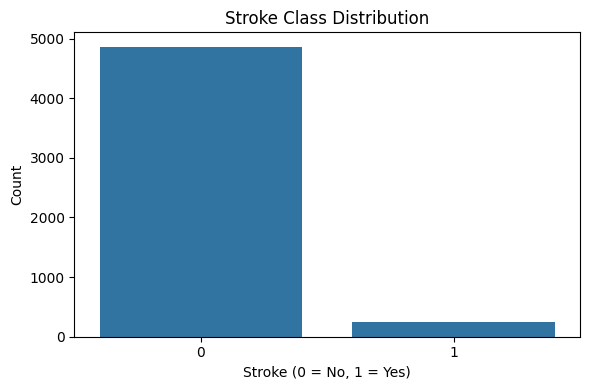

In [149]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="stroke")
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

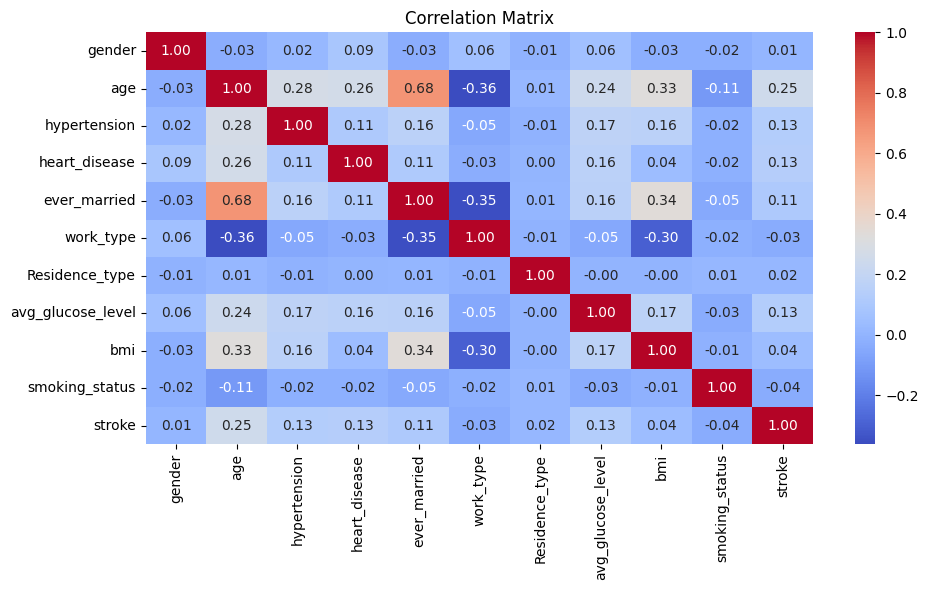

In [153]:
# correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [154]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Linear regression

In [158]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


In [159]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

y_pred_lr_class = np.where(y_pred_lr >= 0.5, 1, 0)

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr_class))

Linear Regression
MSE: 0.04253372048053614
MAE: 0.09212341259930505
R2: 0.08588908431291531
Accuracy: 0.9510763209393346


Decision Tree classifier

In [160]:
from sklearn.tree import DecisionTreeClassifier


In [161]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.9481409001956947
ROC-AUC: 0.8204320987654321
[[969   3]
 [ 50   0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



Random Foret

In [162]:
from sklearn.ensemble import RandomForestClassifier


In [175]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9500978473581213
ROC-AUC: 0.7882201646090534
[[970   2]
 [ 49   1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.33      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.64      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022



Text(0.5, 1.0, 'Feature Importance from Random Forest')

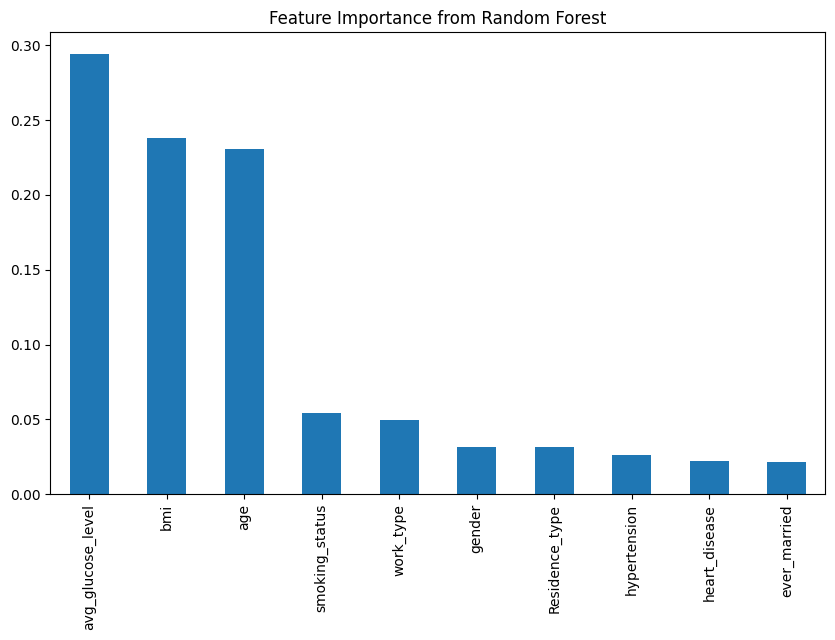

In [164]:
# feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importance from Random Forest")

Knn

In [169]:
from sklearn.neighbors import KNeighborsClassifier


In [170]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN
Accuracy: 0.9442270058708415
ROC-AUC: 0.5776131687242798
[[965   7]
 [ 50   0]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.94      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.94      0.92      1022



Logistic regression

In [171]:
from sklearn.linear_model import LogisticRegression


In [174]:
lor = LogisticRegression(max_iter=1000, random_state=42)
lor.fit(X_train, y_train)

y_pred_lor = lor.predict(X_test)
y_prob_lor = lor.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lor))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lor))
print(confusion_matrix(y_test, y_pred_lor))
print(classification_report(y_test, y_pred_lor))

Logistic Regression
Accuracy: 0.9510763209393346
ROC-AUC: 0.838045267489712
[[972   0]
 [ 50   0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [177]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rows = []

def add(name, y_true, y_pred, y_prob=None):
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    })

add("Logistic Regression", y_test, lor.predict(X_test), lor.predict_proba(X_test)[:, 1])
add("Decision Tree", y_test, dt.predict(X_test), dt.predict_proba(X_test)[:, 1])
add("Random Forest", y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1])
add("KNN", y_test, knn.predict(X_test), knn.predict_proba(X_test)[:, 1])
lin_pred = (lr_model.predict(X_test) >= 0.5).astype(int)
add("Linear Regression", y_test, lin_pred)

metrics_df = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False)
print(metrics_df)

                 Model  Accuracy  Precision  Recall        F1   ROC_AUC
0  Logistic Regression  0.951076   0.000000    0.00  0.000000  0.838045
1        Decision Tree  0.948141   0.000000    0.00  0.000000  0.820432
2        Random Forest  0.950098   0.333333    0.02  0.037736  0.788220
3                  KNN  0.944227   0.000000    0.00  0.000000  0.577613
4    Linear Regression  0.951076   0.000000    0.00  0.000000       NaN


using Oversampling to balance dataset - Minority class ko duplicate karke balance karenge.

In [178]:
from sklearn.utils import resample

stroke_0 = df[df['stroke'] == 0]
stroke_1 = df[df['stroke'] == 1]

stroke_1_upsampled = resample(
    stroke_1,
    replace=True,
    n_samples=len(stroke_0),
    random_state=42
)

balanced_df = pd.concat([
    stroke_0,
    stroke_1_upsampled
])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(balanced_df['stroke'].value_counts())

stroke
0    4861
1    4861
Name: count, dtype: int64


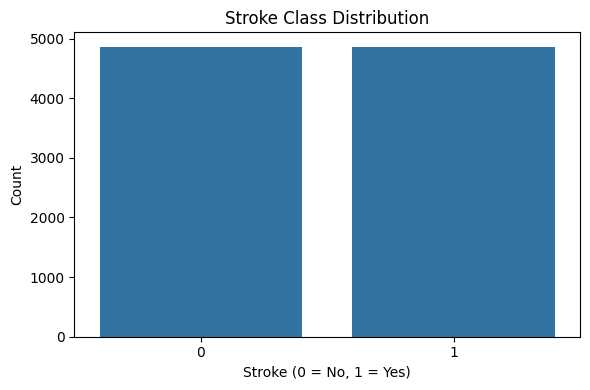

In [181]:
plt.figure(figsize=(6, 4))
sns.countplot(data=balanced_df, x="stroke")
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [180]:
balanced_df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,21.0,0,0,0,2,1,90.16,28.9,2,0
1,0,52.0,1,0,1,3,1,233.29,48.9,1,1
2,1,55.0,0,0,1,3,0,73.57,28.0,2,0
3,0,51.0,0,0,1,2,0,105.63,32.8,1,0
4,0,79.0,0,0,1,2,1,110.85,24.1,0,1


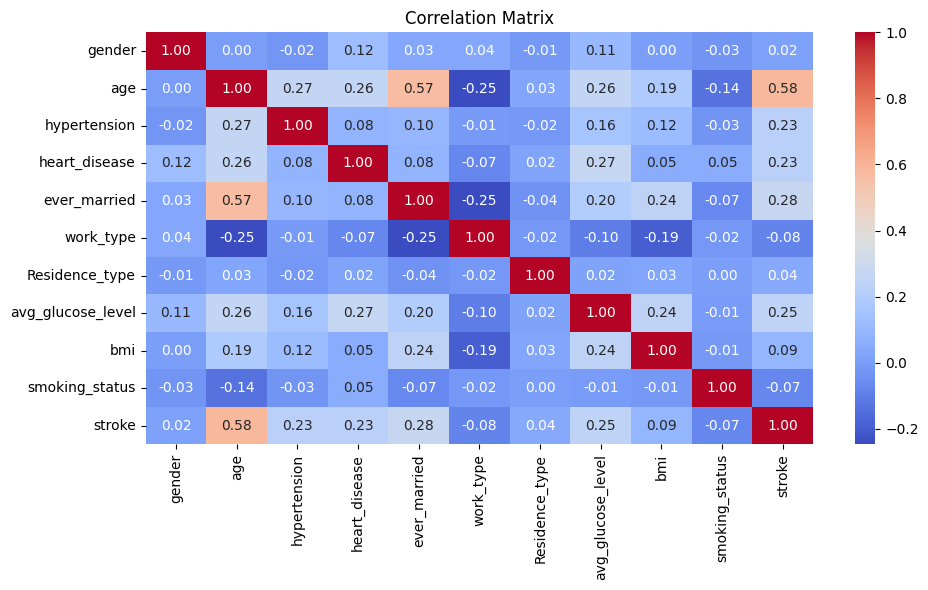

In [182]:
# correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(balanced_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [183]:
X = balanced_df.drop("stroke", axis=1)
y = balanced_df["stroke"]

In [184]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [185]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

y_pred_lr_class = np.where(y_pred_lr >= 0.5, 1, 0)

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr_class))

Linear Regression
MSE: 0.16029010707246422
MAE: 0.32834627536114175
R2: 0.35883940222656896
Accuracy: 0.7645244215938304


In [189]:
lor = LogisticRegression(max_iter=1000, random_state=42)
lor.fit(X_train, y_train)

y_pred_lor = lor.predict(X_test)
y_prob_lor = lor.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lor))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lor))
print(confusion_matrix(y_test, y_pred_lor))
print(classification_report(y_test, y_pred_lor))

Logistic Regression
Accuracy: 0.7655526992287918
ROC-AUC: 0.8458703936321842
[[712 261]
 [195 777]]
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       973
           1       0.75      0.80      0.77       972

    accuracy                           0.77      1945
   macro avg       0.77      0.77      0.77      1945
weighted avg       0.77      0.77      0.77      1945



In [187]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.8087403598971722
ROC-AUC: 0.8791871264892848
[[715 258]
 [114 858]]
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       973
           1       0.77      0.88      0.82       972

    accuracy                           0.81      1945
   macro avg       0.82      0.81      0.81      1945
weighted avg       0.82      0.81      0.81      1945



In [188]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9922879177377892
ROC-AUC: 1.0
[[958  15]
 [  0 972]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       973
           1       0.98      1.00      0.99       972

    accuracy                           0.99      1945
   macro avg       0.99      0.99      0.99      1945
weighted avg       0.99      0.99      0.99      1945



Text(0.5, 1.0, 'Feature Importance from Random Forest')

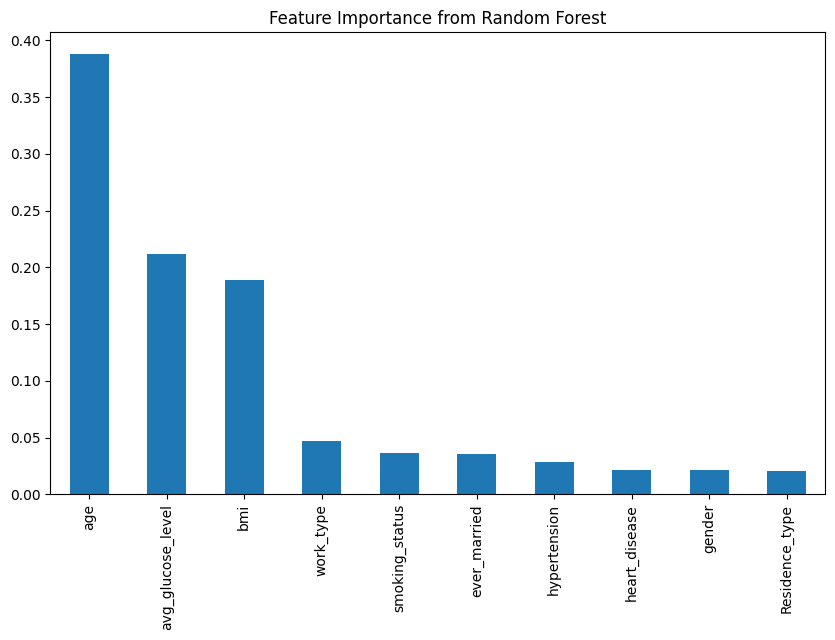

In [190]:
# feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importance from Random Forest")

In [191]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN
Accuracy: 0.9362467866323907
ROC-AUC: 0.972764645426516
[[849 124]
 [  0 972]]
              precision    recall  f1-score   support

           0       1.00      0.87      0.93       973
           1       0.89      1.00      0.94       972

    accuracy                           0.94      1945
   macro avg       0.94      0.94      0.94      1945
weighted avg       0.94      0.94      0.94      1945



In [193]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

rows = []

def add(name, y_true, y_pred, y_prob=None):
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    })

add("Logistic Regression", y_test, lr.predict(X_test), lr.predict_proba(X_test)[:, 1])
add("Decision Tree", y_test, dt.predict(X_test), dt.predict_proba(X_test)[:, 1])
add("Random Forest", y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1])
add("KNN", y_test, knn.predict(X_test), knn.predict_proba(X_test)[:, 1])
lin_pred = (lr_model.predict(X_test) >= 0.5).astype(int)
add("Linear Regression", y_test, lin_pred)

metrics_df = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False)
print(metrics_df)

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
2        Random Forest  0.992288   0.984802  1.000000  0.992343  1.000000
3                  KNN  0.936247   0.886861  1.000000  0.940039  0.972765
1        Decision Tree  0.808740   0.768817  0.882716  0.821839  0.879187
0  Logistic Regression  0.765553   0.748555  0.799383  0.773134  0.845870
4    Linear Regression  0.764524   0.742453  0.809671  0.774606       NaN


In [198]:
# trying to predicting on new data using all models
new_data = pd.DataFrame({"gender": [1], "age": [55], "hypertension": [0], "heart_disease": [0],
                         "ever_married": [1], "work_type": [1], "Residence_type": [1], "avg_glucose_level": [170], "bmi": [38], "smoking_status": ["formerly smoked"]})

new_data['smoking_status'] = le.fit_transform(
    new_data['smoking_status']
)
new_data_scaled = scaler.transform(new_data)

new_pred_lr = lr_model.predict(new_data_scaled)
new_pred_lr_class = np.where(new_pred_lr >= 0.5, 1, 0)

new_pred_logistic = lr.predict(new_data_scaled)

new_pred_dt = dt.predict(new_data_scaled)

new_pred_rf = rf.predict_proba(new_data_scaled)[:, 1]

new_pred_knn_label = knn.predict(new_data_scaled)
print("Predictions for new data:")
print("Linear Regression (probability):", new_pred_lr[0])
print("Linear Regression (class):", new_pred_lr_class[0])
print("Logistic Regression (class):", new_pred_logistic[0])
print("Decision Tree (class):", new_pred_dt[0])
print("Random Forest (probability of stroke):", new_pred_rf[0])
print("KNN (class):", new_pred_knn_label[0])


Predictions for new data:
Linear Regression (probability): 0.47758232275672835
Linear Regression (class): 0
Logistic Regression (class): 0
Decision Tree (class): 1
Random Forest (probability of stroke): 0.18
KNN (class): 1
